# Reação competitiva A → B e A → C 
**Objetivo:** resolver numericamente e plotar apenas as curvas numéricas das concentrações temporais para um sistema competitivo (A → B e A → C).

## Introdução breve (contexto químico)
Consideramos o sistema competitivo (paralelo)
$$\mathrm{A}\xrightarrow{k_1}\mathrm{B}\qquad\text{e}\qquad\mathrm{A}\xrightarrow{k_2}\mathrm{C}.$$

As equações de taxa são:
$$\frac{d[A]}{dt} = -(k_1 + k_2)\,[A],$$
$$\frac{d[B]}{dt} = +k_1\,[A],$$
$$\frac{d[C]}{dt} = +k_2\,[A].$$

Neste notebook mostramos apenas a solução numérica (integração das EDOs) — útil quando desejar estender o mecanismo ou usar condições gerais.


## Uso
Edite a célula de parâmetros e execute as células. A figura mostrará apenas as curvas numéricas obtidas com `odeint`.

In [16]:
# Imports e definição das EDOs
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

def edos(concs, t, k1, k2):
    A, B, C = concs
    dAdt = -(k1 + k2) * A
    dBdt = k1 * A
    dCdt = k2 * A
    return [dAdt, dBdt, dCdt]


In [17]:
# Parâmetros ajustáveis (altere aqui)
k1 = 0.6      # constante para A -> B (s^-1)
k2 = 0.4      # constante para A -> C (s^-1)
A0 = 1.0      # concentração inicial de A (mol·L^-1)
B0 = 0.0      # concentração inicial de B
C0 = 0.0      # concentração inicial de C
t_max = 10.0   # tempo máximo (s)
n_points = 500  # número de pontos

t = np.linspace(0, t_max, n_points)
y0 = [A0, B0, C0]

# Resolução numérica
sol = odeint(edos, y0, t, args=(k1, k2))
A_t, B_t, C_t = sol.T


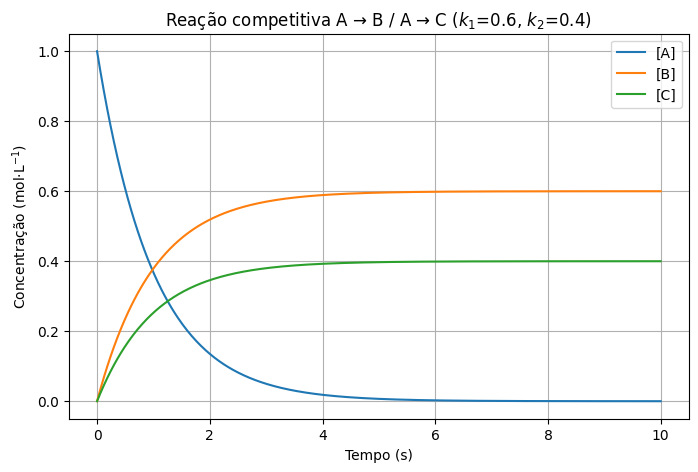

Constante total k_tot = 1.0000 s^-1 (tau = 1.0000 s)
Rendimento final estimado [B](∞) = 0.60000  mol·L^-1  (frac_B = 0.600)
Rendimento final estimado [C](∞) = 0.40000  mol·L^-1  (frac_C = 0.400)


In [18]:
# Plot 
plt.figure(figsize=(8,5))
plt.plot(t, A_t, label='[A]')
plt.plot(t, B_t, label='[B]')
plt.plot(t, C_t, label='[C]')
plt.xlabel('Tempo (s)')
plt.ylabel('Concentração (mol·L$^{-1}$)')
plt.title(f'Reação competitiva A → B / A → C ($k_1$={k1}, $k_2$={k2}) ')
plt.legend()
plt.grid(True)
plt.show()

# Calcular e imprimir rendimentos finais (usando expressão fechada para referência)
k_tot = k1 + k2
B_inf = A0 * (k1 / k_tot)
C_inf = A0 * (k2 / k_tot)
print(f"Constante total k_tot = {k_tot:.4f} s^-1 (tau = {1/k_tot:.4f} s)")
print(f"Rendimento final estimado [B](∞) = {B_inf:.5f}  mol·L^-1  (frac_B = {k1/k_tot:.3f})")
print(f"Rendimento final estimado [C](∞) = {C_inf:.5f}  mol·L^-1  (frac_C = {k2/k_tot:.3f})")
